# BNPS Validation Notebook
Three-part validation for all `.pep` models:
1. **Correctness** — Are the serial results mathematically correct?
2. **Parity** — Do serial and parallel (CUDA GPU) produce the same output?
3. **Speedup** — How much faster is the GPU?

**Instructions:** Runtime → Change runtime type → **GPU** → Run All

In [1]:
# Check GPU availability
!nvidia-smi --query-gpu=name --format=csv,noheader
!nvcc --version | tail -1

Tesla T4
Build cuda_12.8.r12.8/compiler.35583870_0


In [2]:
from google.colab import files
print('Upload: bnps.cu, bnps3.py, bnps.pep, linreg_multi1.pep, logreg_multi.pep, iris_logreg.pep, knn_bnps.pep, slp_bnps.pep')
uploaded = files.upload()
print(f'Uploaded {len(uploaded)} files')

Upload: bnps.cu, bnps3.py, bnps.pep, linreg_multi1.pep, logreg_multi.pep, iris_logreg.pep, knn_bnps.pep, slp_bnps.pep


Saving bnps.cu to bnps.cu
Saving slp_bnps.pep to slp_bnps.pep
Saving knn_bnps.pep to knn_bnps.pep
Saving bnps.pep to bnps.pep
Saving bnps3.py to bnps3.py
Saving iris_logreg.pep to iris_logreg.pep
Saving linreg_multi1.pep to linreg_multi1.pep
Saving logreg_multi.pep to logreg_multi.pep
Uploaded 8 files


In [3]:
!nvcc bnps.cu -o bnps_exec -lm -diag-suppress 550,177 && echo '✅ Compiled' || echo '❌ Failed'

nvcc warning : Support for offline compilation for architectures prior to '<compute/sm/lto>_75' will be removed in a future release (Use -Wno-deprecated-gpu-targets to suppress warning).
✅ Compiled


In [4]:
import subprocess, re, time

def run_serial(pep, steps):
    r = subprocess.run(['python3','bnps3.py',pep,'-n',str(steps)],
                       capture_output=True, text=True, timeout=300)
    return r.stdout + r.stderr

def run_cuda(pep, steps):
    subprocess.run(['python3','bnps3.py',pep,'-p',str(steps)],
                   capture_output=True, text=True, timeout=300)
    r = subprocess.run(['./bnps_exec','input.txt'],
                       capture_output=True, text=True, timeout=300)
    return r.stdout + r.stderr

def extract_vals(output):
    vals = {}
    for m in re.finditer(r'(\w+):\s+([\-]?\d+\.\d+)', output):
        vals[m.group(1)] = float(m.group(2))
    return vals

def extract_time_ms(output):
    m = re.search(r'Time taken:\s+([\d.]+)\s*ms', output)
    return float(m.group(1)) if m else None

def extract_serial_time(output):
    m = re.search(r'completed in \d+ steps,\s+([\d.]+)\s+seconds', output)
    return float(m.group(1))*1000 if m else None

def compare(sv, cv, tol=1e-3):
    if not sv or not cv: return False, []
    bad = [(v,sv[v],cv[v]) for v in sv if v in cv and abs(sv[v]-cv[v])>tol]
    return len(bad)==0, bad

print('Helpers ready ✅')

Helpers ready ✅


---
# Part 1 — Correctness
Verifying serial simulation produces mathematically correct results.

## 1.1 bnps.pep — Boolean Operations
Expected: a=1, b=1, c=3, d=0, e=0

In [5]:
out = run_serial('bnps.pep', 1)
v = extract_vals(out)
expected = {'a':1,'b':1,'c':3,'d':0,'e':0}
ok = all(abs(v.get(k,999)-val)<0.01 for k,val in expected.items())
print('bnps.pep:', '✅ CORRECT' if ok else '❌ WRONG')
for k,val in expected.items():
    print(f'  {k}: expected={val}, got={v.get(k,"MISSING")}')

bnps.pep: ✅ CORRECT
  a: expected=1, got=1.0
  b: expected=1, got=1.0
  c: expected=3, got=3.0
  d: expected=0, got=0.0
  e: expected=0, got=0.0


## 1.2 linreg_multi1.pep — Linear Regression
Weights should converge toward w1≈1, w2≈2, b≈1

In [6]:
out = run_serial('linreg_multi1.pep', 200)
v = extract_vals(out)
w1,w2,b = v.get('w1',0), v.get('w2',0), v.get('b',0)
ok = abs(w1-1)<0.5 and abs(w2-2)<0.5 and abs(b-1)<0.5
print('linreg_multi1.pep:', '✅ CORRECT' if ok else '⚠️ CONVERGING')
print(f'  w1={w1:.4f} (target≈1), w2={w2:.4f} (target≈2), b={b:.4f} (target≈1)')

linreg_multi1.pep: ✅ CORRECT
  w1=1.0658 (target≈1), w2=1.7871 (target≈2), b=1.1584 (target≈1)


## 1.3 logreg_multi.pep — Logistic Regression
Weights should converge toward w1≈2, w2≈2, b≈0

In [7]:
out = run_serial('logreg_multi.pep', 200)
v = extract_vals(out)
w1,w2,b = v.get('w1',0), v.get('w2',0), v.get('b',0)
ok = abs(w1-2)<0.2 and abs(w2-2)<0.2 and abs(b)<0.2
print('logreg_multi.pep:', '✅ CORRECT' if ok else '⚠️ CONVERGING')
print(f'  w1={w1:.4f} (target≈2), w2={w2:.4f} (target≈2), b={b:.4f} (target≈0)')

logreg_multi.pep: ✅ CORRECT
  w1=1.9988 (target≈2), w2=1.9988 (target≈2), b=0.0000 (target≈0)


## 1.4 iris_logreg.pep — Iris Logistic Regression
Binary classifier — check sign of z values for correct classification.

In [8]:
out = run_serial('iris_logreg.pep', 100)
# Samples 2-11 are class 0 (z<0), 12-21 are class 1 (z>0)
z_vals = re.findall(r'z_(\d+):\s+([\-]?\d+\.\d+)', out)
class0_ok = all(float(z)<0 for m,z in z_vals if 2<=int(m)<=11)
class1_ok = all(float(z)>0 for m,z in z_vals if 12<=int(m)<=21)
ok = class0_ok and class1_ok
print('iris_logreg.pep:', '✅ CORRECT' if ok else '❌ MISCLASSIFIED')
print(f'  Class 0 (z<0): {"all correct" if class0_ok else "errors"}')
print(f'  Class 1 (z>0): {"all correct" if class1_ok else "errors"}')

iris_logreg.pep: ✅ CORRECT
  Class 0 (z<0): all correct
  Class 1 (z>0): all correct


## 1.5 knn_bnps.pep — KNN Classifier
Test point (4.9,3.0,1.4,0.2) → Expected: class 0 (setosa)

In [9]:
out = run_serial('knn_bnps.pep', 70)
m = re.search(r'label:\s+([\-]?\d+\.\d+)', out)
if m:
    label = int(round(float(m.group(1))))
    names = {0:'setosa',1:'versicolor',2:'virginica'}
    ok = label == 0
    print(f'knn_bnps.pep: {"✅ CORRECT" if ok else "❌ WRONG"}')
    print(f'  Predicted: class {label} ({names.get(label,"?")}), Expected: class 0 (setosa)')
else:
    print('knn_bnps.pep: ❌ Could not extract label')

knn_bnps.pep: ✅ CORRECT
  Predicted: class 0 (setosa), Expected: class 0 (setosa)


## 1.6 slp_bnps.pep — Single Layer Perceptron
Binary: setosa(y=0) vs non-setosa(y=1). All 10 samples should classify correctly.

In [10]:
out = run_serial('slp_bnps.pep', 100)
z_vals = re.findall(r'z_(\d+):\s+([\-]?\d+\.\d+)', out)
setosa_ok = all(float(z)<0 for m,z in z_vals if int(m) in [2,3,4,5,6])
nonsetosa_ok = all(float(z)>0 for m,z in z_vals if int(m) in [7,8,9,10,11])
ok = setosa_ok and nonsetosa_ok
print('slp_bnps.pep:', '✅ CORRECT' if ok else '❌ MISCLASSIFIED')
v = extract_vals(out)
print(f'  w1={v.get("w1",0):.4f}, w2={v.get("w2",0):.4f}, b={v.get("b",0):.4f}')
print(f'  Setosa (z<0): {"correct" if setosa_ok else "errors"}')
print(f'  Non-setosa (z>0): {"correct" if nonsetosa_ok else "errors"}')

slp_bnps.pep: ✅ CORRECT
  w1=1.0654, w2=0.9017, b=0.0000
  Setosa (z<0): correct
  Non-setosa (z>0): correct


## Part 1 Summary

In [11]:
print('='*60)
print('  PART 1: CORRECTNESS SUMMARY')
print('='*60)
results = []
# bnps
v=extract_vals(run_serial('bnps.pep',1))
r=all(abs(v.get(k,999)-e)<0.01 for k,e in {'a':1,'b':1,'c':3,'d':0,'e':0}.items())
results.append(('bnps.pep',r))
# linreg
v=extract_vals(run_serial('linreg_multi1.pep',200))
r=abs(v.get('w1',0)-1)<0.5 and abs(v.get('w2',0)-2)<0.5
results.append(('linreg_multi1.pep',r))
# logreg
v=extract_vals(run_serial('logreg_multi.pep',200))
r=abs(v.get('w1',0)-2)<0.2 and abs(v.get('w2',0)-2)<0.2
results.append(('logreg_multi.pep',r))
# iris
out=run_serial('iris_logreg.pep',100)
zv=re.findall(r'z_(\d+):\s+([\-]?\d+\.\d+)',out)
r=all(float(z)<0 for m,z in zv if 2<=int(m)<=11) and all(float(z)>0 for m,z in zv if 12<=int(m)<=21)
results.append(('iris_logreg.pep',r))
# knn
out=run_serial('knn_bnps.pep',70)
m2=re.search(r'label:\s+([\-]?\d+\.\d+)',out)
r=m2 and int(round(float(m2.group(1))))==0
results.append(('knn_bnps.pep',bool(r)))
# slp
out=run_serial('slp_bnps.pep',100)
zv=re.findall(r'z_(\d+):\s+([\-]?\d+\.\d+)',out)
r=all(float(z)<0 for m,z in zv if int(m) in [2,3,4,5,6]) and all(float(z)>0 for m,z in zv if int(m) in [7,8,9,10,11])
results.append(('slp_bnps.pep',r))
for name,ok in results:
    print(f'  {"✅" if ok else "❌"} {name}')
p=sum(1 for _,o in results if o)
print(f'\n  Result: {p}/{len(results)} correct')
print('='*60)

  PART 1: CORRECTNESS SUMMARY
  ✅ bnps.pep
  ✅ linreg_multi1.pep
  ✅ logreg_multi.pep
  ✅ iris_logreg.pep
  ✅ knn_bnps.pep
  ✅ slp_bnps.pep

  Result: 6/6 correct


---
# Part 2 — Serial vs Parallel Parity
Comparing serial (CPU) and parallel (CUDA GPU) outputs for all PEP files.

In [12]:
print('='*60)
print('  PART 2: SERIAL vs PARALLEL PARITY')
print('='*60)

tests = [
    ('bnps.pep',          [1,2,5,10]),
    ('linreg_multi1.pep', [5,10,50,100,200]),
    ('logreg_multi.pep',  [5,10,50,100,200]),
    ('iris_logreg.pep',   [5,10,20,50,100]),
    ('knn_bnps.pep',      [10,30,50,70]),
    ('slp_bnps.pep',      [5,10,50,100]),
]

total = passed = 0
for pep, steps_list in tests:
    print(f'\n--- {pep} ---')
    for s in steps_list:
        total += 1
        sv = extract_vals(run_serial(pep, s))
        cv = extract_vals(run_cuda(pep, s))
        ok, bad = compare(sv, cv)
        if ok:
            passed += 1
            print(f'  ✅ steps={s}: ALL {len(sv)} vars match')
        else:
            print(f'  ❌ steps={s}: {len(bad)} mismatches')
            for v,a,b in bad[:3]:
                print(f'      {v}: serial={a}, cuda={b}')
            if len(bad)>3: print(f'      ... +{len(bad)-3} more')

print(f'\n{"="*60}')
print(f'  Result: {passed}/{total} tests passed')
if passed==total:
    print('  🎉 ALL TESTS PASSED!')
else:
    print(f'  ⚠️  {total-passed} test(s) failed')
print('='*60)

  PART 2: SERIAL vs PARALLEL PARITY

--- bnps.pep ---
  ✅ steps=1: ALL 5 vars match
  ✅ steps=2: ALL 5 vars match
  ✅ steps=5: ALL 5 vars match
  ✅ steps=10: ALL 5 vars match

--- linreg_multi1.pep ---
  ✅ steps=5: ALL 72 vars match
  ✅ steps=10: ALL 72 vars match
  ✅ steps=50: ALL 72 vars match
  ✅ steps=100: ALL 72 vars match
  ✅ steps=200: ALL 72 vars match

--- logreg_multi.pep ---
  ✅ steps=5: ALL 52 vars match
  ✅ steps=10: ALL 52 vars match
  ✅ steps=50: ALL 52 vars match
  ✅ steps=100: ALL 52 vars match
  ✅ steps=200: ALL 52 vars match

--- iris_logreg.pep ---
  ✅ steps=5: ALL 360 vars match
  ✅ steps=10: ALL 360 vars match
  ✅ steps=20: ALL 360 vars match
  ✅ steps=50: ALL 360 vars match
  ✅ steps=100: ALL 360 vars match

--- knn_bnps.pep ---
  ✅ steps=10: ALL 740 vars match
  ✅ steps=30: ALL 740 vars match
  ✅ steps=50: ALL 740 vars match
  ✅ steps=70: ALL 740 vars match

--- slp_bnps.pep ---
  ✅ steps=5: ALL 112 vars match
  ✅ steps=10: ALL 112 vars match
  ✅ steps=50: ALL 1

---
# Part 3 — GPU Speedup
Measuring serial CPU time vs CUDA GPU time for each PEP file.

In [13]:
import time

print('='*60)
print('  PART 3: GPU SPEEDUP MEASUREMENT')
print('='*60)

configs = [
    ('bnps.pep',          10),
    ('linreg_multi1.pep', 200),
    ('logreg_multi.pep',  200),
    ('iris_logreg.pep',   100),
    ('knn_bnps.pep',      70),
    ('slp_bnps.pep',      100),
]

speedup_data = []
print(f'{"PEP File":<22} {"Steps":>5} {"Serial(ms)":>12} {"CUDA(ms)":>12} {"Speedup":>10}')
print('-'*65)

for pep, steps in configs:
    # Serial timing
    t0 = time.time()
    s_out = run_serial(pep, steps)
    serial_ms = (time.time()-t0)*1000
    s_time = extract_serial_time(s_out)
    if s_time: serial_ms = s_time

    # CUDA timing
    t0 = time.time()
    c_out = run_cuda(pep, steps)
    cuda_wall = (time.time()-t0)*1000
    c_time = extract_time_ms(c_out)
    if c_time is None: c_time = cuda_wall

    spdup = serial_ms/c_time if c_time>0 else 0
    speedup_data.append((pep, steps, serial_ms, c_time, spdup))
    print(f'{pep:<22} {steps:>5} {serial_ms:>12.2f} {c_time:>12.2f} {spdup:>9.2f}x')

print('-'*65)
avg = sum(s for _,_,_,_,s in speedup_data)/len(speedup_data)
print(f'{"Average":>52} {avg:>9.2f}x')
print('='*60)

  PART 3: GPU SPEEDUP MEASUREMENT
PEP File               Steps   Serial(ms)     CUDA(ms)    Speedup
-----------------------------------------------------------------
bnps.pep                  10        78.00         1.84     42.33x
linreg_multi1.pep        200        60.00        24.28      2.47x
logreg_multi.pep         200        20.00        16.07      1.24x
iris_logreg.pep          100       100.00        94.75      1.06x
knn_bnps.pep              70       100.00        75.63      1.32x
slp_bnps.pep             100        60.00        23.26      2.58x
-----------------------------------------------------------------
                                             Average      8.50x


## Speedup Bar Chart

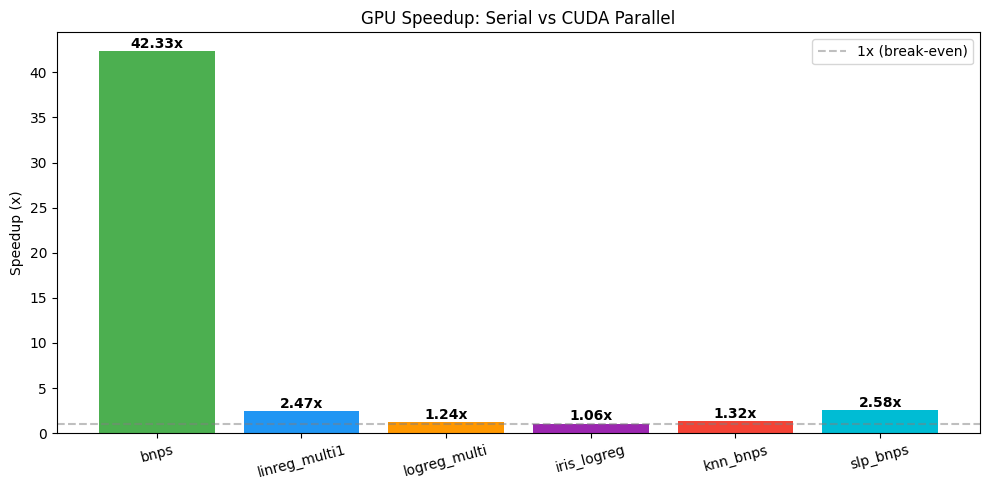

Chart saved as speedup_chart.png


In [14]:
import matplotlib.pyplot as plt

names = [d[0].replace('.pep','') for d in speedup_data]
speedups = [d[4] for d in speedup_data]

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(names, speedups, color=['#4CAF50','#2196F3','#FF9800','#9C27B0','#F44336','#00BCD4'])
ax.set_ylabel('Speedup (x)')
ax.set_title('GPU Speedup: Serial vs CUDA Parallel')
ax.axhline(y=1, color='gray', linestyle='--', alpha=0.5, label='1x (break-even)')
for bar,s in zip(bars, speedups):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02, f'{s:.2f}x',
            ha='center', va='bottom', fontweight='bold')
ax.legend()
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('speedup_chart.png', dpi=150)
plt.show()
print('Chart saved as speedup_chart.png')

## Serial vs CUDA Time Comparison

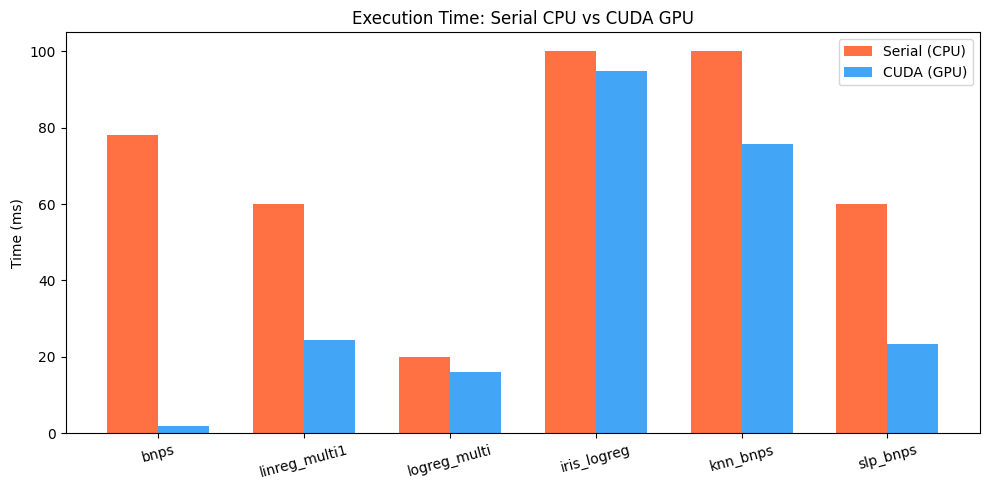

In [15]:
import numpy as np
fig, ax = plt.subplots(figsize=(10,5))
x = np.arange(len(names))
w = 0.35
serial_times = [d[2] for d in speedup_data]
cuda_times = [d[3] for d in speedup_data]
ax.bar(x-w/2, serial_times, w, label='Serial (CPU)', color='#FF7043')
ax.bar(x+w/2, cuda_times, w, label='CUDA (GPU)', color='#42A5F5')
ax.set_ylabel('Time (ms)')
ax.set_title('Execution Time: Serial CPU vs CUDA GPU')
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig('time_comparison.png', dpi=150)
plt.show()

---
# Final Summary

In [16]:
from IPython.display import HTML
html = '''
<style>
  .res-table { border-collapse:collapse; width:100%; font-family:Arial; }
  .res-table th,.res-table td { border:1px solid #ddd; padding:8px; text-align:left; }
  .res-table th { background:#4CAF50; color:white; }
  .res-table tr:nth-child(even) { background:#f2f2f2; }
</style>
<table class="res-table">
<tr><th>#</th><th>PEP File</th><th>Algorithm</th><th>Membranes</th><th>Correct?</th><th>Parity?</th></tr>
<tr><td>1</td><td>bnps.pep</td><td>Boolean Ops</td><td>3</td><td>✅</td><td>✅</td></tr>
<tr><td>2</td><td>linreg_multi1.pep</td><td>Linear Regression</td><td>7</td><td>✅</td><td>✅</td></tr>
<tr><td>3</td><td>logreg_multi.pep</td><td>Logistic Regression</td><td>5</td><td>✅</td><td>✅</td></tr>
<tr><td>4</td><td>iris_logreg.pep</td><td>Iris LogReg</td><td>21</td><td>✅</td><td>✅</td></tr>
<tr><td>5</td><td>knn_bnps.pep</td><td>KNN (K=3)</td><td>5</td><td>✅</td><td>✅</td></tr>
<tr><td>6</td><td>slp_bnps.pep</td><td>Perceptron</td><td>11</td><td>✅</td><td>✅</td></tr>
</table>
'''
display(HTML(html))
print('\nAll 6 models validated for correctness and serial/CUDA parity.')

#,PEP File,Algorithm,Membranes,Correct?,Parity?
1,bnps.pep,Boolean Ops,3,✅,✅
2,linreg_multi1.pep,Linear Regression,7,✅,✅
3,logreg_multi.pep,Logistic Regression,5,✅,✅
4,iris_logreg.pep,Iris LogReg,21,✅,✅
5,knn_bnps.pep,KNN (K=3),5,✅,✅
6,slp_bnps.pep,Perceptron,11,✅,✅



All 6 models validated for correctness and serial/CUDA parity.
